In [ ]:
# from google.colab import drive
# drive.mount("/content/drive")

%pip install -q \
  "diffusers==0.25.1" \
  "transformers>=4.41.0,<5.0.0" \
  "huggingface_hub==0.25.2" \
  accelerate ftfy regex tqdm scikit-learn


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.7/41.7 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.7/41.7 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import os
import math
import glob
import json
from typing import List, Optional, Dict

import numpy as np
from PIL import Image

import torch
from torch import nn
from tqdm.auto import tqdm

from diffusers import StableDiffusionPipeline, DDIMScheduler, DDIMInverseScheduler
from sklearn.metrics import roc_curve, auc

In [ ]:
# Device pick
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Using device:", device)


In [ ]:
# Root of your project
ROOT = "/content/drive/MyDrive/Treering_pipeline"

run_name = "colab_100"

watermarked_dir = "/content/drive/MyDrive/Treering_pipeline/outputs/colab_100/watermarked"
attacked_dir    = "/content/drive/MyDrive/Treering_pipeline/outputs/colab_100/attacked"

print("Watermarked dir:", watermarked_dir)
print("Attacked dir:", attacked_dir)
print("Num watermarked images:", len(glob.glob(os.path.join(watermarked_dir, "*.png"))))
print("Num attacked images:", len(glob.glob(os.path.join(attacked_dir, "*.png"))))


Watermarked dir: /content/drive/MyDrive/Treering_pipeline/outputs/colab_100/watermarked
Attacked dir: /content/drive/MyDrive/Treering_pipeline/outputs/colab_100/attacked
Num watermarked images: 100
Num attacked images: 100


In [ ]:
def make_radius_map(h: int, w: int, device: torch.device) -> torch.Tensor:
    ys = torch.arange(h, device=device) - (h - 1) / 2.0
    xs = torch.arange(w, device=device) - (w - 1) / 2.0
    yy, xx = torch.meshgrid(ys, xs, indexing="ij")
    return torch.sqrt(xx * xx + yy * yy)


class TreeRingWatermarker:
    def __init__(
        self,
        channels: int,
        height: int,
        width: int,
        w_channel: int = 3,
        w_pattern: str = "ring",
        w_radius: int = 16,
        key_seed: int = 12345,
        device: Optional[torch.device] = None,
    ):
        self.device = torch.device("cpu") if device is None else device
        self.channels = channels
        self.height = height
        self.width = width
        self.w_channel = w_channel
        self.w_pattern = w_pattern
        self.w_radius = w_radius

        r = make_radius_map(height, width, self.device)
        self.radius_map = r
        self.mask = r <= float(w_radius)

        self.key_rand: Dict[int, torch.Tensor] = {}
        self.key_ring: Dict[int, torch.Tensor] = {}
        self.r_int = torch.round(r).long()

        self.rng = torch.Generator(device=self.device)
        self.rng.manual_seed(key_seed)

    def _key_rand(self, ch: int) -> torch.Tensor:
        if ch in self.key_rand:
            return self.key_rand[ch]
        real = torch.randn_like(self.radius_map, generator=self.rng)
        imag = torch.randn_like(self.radius_map, generator=self.rng)
        key = torch.complex(real, imag) * self.mask
        self.key_rand[ch] = key
        return key

    def _key_ring(self, ch: int) -> torch.Tensor:
        if ch in self.key_ring:
            return self.key_ring[ch]

        key = torch.zeros_like(self.radius_map, dtype=torch.complex64)
        unique_radii = torch.unique(self.r_int[self.mask])
        for rad in unique_radii:
            ring_mask = (self.r_int == rad) & self.mask
            if not torch.any(ring_mask):
                continue
            real = torch.randn(1, generator=self.rng, device=self.device)
            imag = torch.randn(1, generator=self.rng, device=self.device)
            key[ring_mask] = torch.complex(real, imag)[0]

        self.key_ring[ch] = key
        return key

    def get_key_fft(self, ch: int) -> torch.Tensor:
        if self.w_pattern == "zeros":
            return torch.zeros_like(self.radius_map, dtype=torch.complex64)
        elif self.w_pattern == "rand":
            return self._key_rand(ch)
        elif self.w_pattern == "ring":
            return self._key_ring(ch)
        else:
            raise ValueError(f"Unknown pattern {self.w_pattern}")


In [ ]:
model_id = "CompVis/stable-diffusion-v1-4"
height = 512
width = 512
num_inference_steps = 50  # same as during generation

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16 if device.type != "cpu" else torch.float32,
)
pipe.scheduler = DDIMScheduler.from_config(pipe.scheduler.config)
pipe = pipe.to(device)
pipe.enable_attention_slicing()

# Inverse scheduler using the same noise schedule
inv_scheduler = DDIMInverseScheduler.from_config(pipe.scheduler.config)

print("Loaded pipeline and schedulers")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

scheduler_config-checkpoint.json:   0%|          | 0.00/209 [00:00<?, ?B/s]

...

text_encoder/model.safetensors:   0%|          | 0.00/492M [00:00<?, ?B/s]

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!
The config attributes {'skip_prk_steps': True} were passed to DDIMInverseScheduler, but are not expected and will be ignored. Please verify your scheduler_config.json configuration file.


Loaded pipeline and schedulers


In [ ]:
# %pip uninstall -y peft


Found existing installation: peft 0.18.0
Uninstalling peft-0.18.0:
  Successfully uninstalled peft-0.18.0


In [ ]:
@torch.no_grad()
def image_to_latent(vae, image: Image.Image, device: torch.device, height: int, width: int):
    # Resize and convert to tensor in [0, 1]
    image = image.convert("RGB").resize((width, height), resample=Image.BICUBIC)
    img = np.array(image).astype(np.float32) / 255.0
    img = img[None].transpose(0, 3, 1, 2)  # NCHW

    # Match VAE dtype (float16 on GPU, float32 on CPU)
    img = torch.from_numpy(img).to(device=device, dtype=vae.dtype)

    # Scale to [-1, 1]
    img = img * 2.0 - 1.0

    # Encode with VAE
    posterior = vae.encode(img).latent_dist
    latents = posterior.sample()
    # Scale same as Stable Diffusion
    latents = latents * 0.18215
    return latents


In [ ]:
@torch.no_grad()
def get_empty_text_embeddings(pipe, device):
    # Use empty prompt for both conditional and unconditional branches
    text_inputs = pipe.tokenizer(
        ["", ""],
        padding="max_length",
        max_length=pipe.tokenizer.model_max_length,
        return_tensors="pt",
    )
    text_embeddings = pipe.text_encoder(text_inputs.input_ids.to(device))[0]
    return text_embeddings


@torch.no_grad()
def ddim_invert_latent(
    pipe,
    inv_scheduler,
    latent_x0: torch.Tensor,
    num_inference_steps: int = 50,
    guidance_scale: float = 7.5,
):
    """
    Approximate the initial noise latent x_T from x0 using DDIMInverseScheduler.
    latent_x0: shape [1, 4, H, W]
    Returns x_T with same shape.
    """
    device = latent_x0.device

    # Set timesteps for inverse scheduler
    inv_scheduler.set_timesteps(num_inference_steps, device=device)
    timesteps = inv_scheduler.timesteps

    text_embeddings = get_empty_text_embeddings(pipe, device)

    # Start from x0 at the smallest timestep
    latents = latent_x0

    for i, t in enumerate(tqdm(timesteps, desc="DDIM inversion", leave=False)):
        # Classifier free guidance structure
        latent_model_input = torch.cat([latents] * 2)
        latent_model_input = inv_scheduler.scale_model_input(latent_model_input, t)

        noise_pred = pipe.unet(
            latent_model_input,
            t,
            encoder_hidden_states=text_embeddings,
        ).sample

        # Because cond and uncond are identical (both empty),
        # guidance_scale effectively does nothing, but we keep the formula.
        noise_uncond, noise_text = noise_pred.chunk(2)
        noise_pred = noise_uncond + guidance_scale * (noise_text - noise_uncond)

        # Inverse step progresses from x_t to x_{t+1}
        inv_out = inv_scheduler.step(
            model_output=noise_pred,
            timestep=t,
            sample=latents,
            return_dict=True,
        )
        latents = inv_out.prev_sample

    return latents


In [ ]:
@torch.no_grad()
def compute_detection_distance_for_latent(
    watermarker: TreeRingWatermarker,
    latent_xT: torch.Tensor,
    w_channel: int = 3,
) -> float:
    """
    latent_xT: [1, C, H, W] on same device as pipe (usually GPU)
    Detection distance d_det = mean | key - FFT(latent_xT)_mask |
    """
    # Move the relevant channel to CPU and cast to float32 for FFT
    x = latent_xT[0, w_channel].detach().to("cpu", dtype=torch.float32)

    # FFT expects float, will return complex64
    fft_x = torch.fft.fft2(x)
    fft_x = torch.fft.fftshift(fft_x)

    key_fft = watermarker.get_key_fft(w_channel)  # complex64 on CPU
    mask = watermarker.mask

    # Make sure dtypes match
    key_fft = key_fft.to(dtype=fft_x.dtype)

    diff = key_fft[mask] - fft_x[mask]
    d = torch.mean(torch.abs(diff)).item()
    return float(d)

In [ ]:
latent_h = height // 8
latent_w = width // 8

# pipe.unet.in_channels is 4 for SD v1.4
channels = pipe.unet.in_channels

watermarker = TreeRingWatermarker(
    channels=channels,
    height=latent_h,
    width=latent_w,
    w_channel=3,          # same as your run_tree_ring_watermark script
    w_pattern="ring",
    w_radius=16,
    key_seed=12345,
    device=torch.device("cpu"),
)

print("Watermarker ready. Latent size:", latent_h, latent_w)


Watermarker ready. Latent size: 64 64


/tmp/ipython-input-3608042372.py:5: FutureWarning: Accessing config attribute `in_channels` directly via 'UNet2DConditionModel' object attribute is deprecated. Please access 'in_channels' over 'UNet2DConditionModel's config object instead, e.g. 'unet.config.in_channels'.
  channels = pipe.unet.in_channels


In [ ]:
@torch.no_grad()
def evaluate_dir(
    img_dir: str,
    pipe,
    inv_scheduler,
    watermarker: TreeRingWatermarker,
    w_channel: int = 3,
    num_inference_steps: int = 50,
    max_images: Optional[int] = None,
) -> Dict[str, float]:
    paths = sorted(glob.glob(os.path.join(img_dir, "*.png")))
    if max_images is not None:
        paths = paths[:max_images]

    print(f"Evaluating {len(paths)} images from {img_dir}")

    scores = {}
    for p in tqdm(paths, desc=os.path.basename(img_dir)):
        img = Image.open(p)
        latents_x0 = image_to_latent(pipe.vae, img, device, height, width)
        latents_xT = ddim_invert_latent(
            pipe, inv_scheduler, latents_x0, num_inference_steps=num_inference_steps
        )
        d = compute_detection_distance_for_latent(
            watermarker, latents_xT, w_channel=w_channel
        )
        scores[os.path.basename(p)] = d

    return scores


In [ ]:
max_eval_images = None  # or smaller number for a quick test

wm_scores = evaluate_dir(
    watermarked_dir,
    pipe,
    inv_scheduler,
    watermarker,
    w_channel=3,
    num_inference_steps=num_inference_steps,
    max_images=max_eval_images,
)

atk_scores = evaluate_dir(
    attacked_dir,
    pipe,
    inv_scheduler,
    watermarker,
    w_channel=3,
    num_inference_steps=num_inference_steps,
    max_images=max_eval_images,
)

print("Example watermarked scores:", list(wm_scores.items())[:3])
print("Example attacked scores:", list(atk_scores.items())[:3])


Evaluating 100 images from /content/drive/MyDrive/Treering_pipeline/outputs/colab_100/watermarked


watermarked:   0%|          | 0/100 [00:00<?, ?it/s]

DDIM inversion:   0%|          | 0/50 [00:00<?, ?it/s]

DDIM inversion:   0%|          | 0/50 [00:00<?, ?it/s]

DDIM inversion:   0%|          | 0/50 [00:00<?, ?it/s]

...

DDIM inversion:   0%|          | 0/50 [00:00<?, ?it/s]

DDIM inversion:   0%|          | 0/50 [00:00<?, ?it/s]

DDIM inversion:   0%|          | 0/50 [00:00<?, ?it/s]

DDIM inversion:   0%|          | 0/50 [00:00<?, ?it/s]

Example watermarked scores: [('idx00000_b0.png', 25.371431350708008), ('idx00001_b0.png', 29.28619384765625), ('idx00002_b0.png', 23.066123962402344)]
Example attacked scores: [('idx00000_b0_attacked.png', 31.840463638305664), ('idx00001_b0_attacked.png', 37.08363723754883), ('idx00002_b0_attacked.png', 34.498592376708984)]


In [ ]:
import matplotlib.pyplot as plt

def summarize_scores(name, scores_dict):
    vals = np.array(list(scores_dict.values()))
    print(f"{name}  count={len(vals)}  mean={vals.mean():.4f}  std={vals.std():.4f}  "
          f"min={vals.min():.4f}  max={vals.max():.4f}")
    return vals

wm_vals = summarize_scores("Watermarked", wm_scores)
atk_vals = summarize_scores("Attacked   ", atk_scores)


Watermarked  count=100  mean=27.0073  std=2.0378  min=22.7517  max=33.3252
Attacked     count=100  mean=35.3929  std=2.5617  min=24.5134  max=41.3410


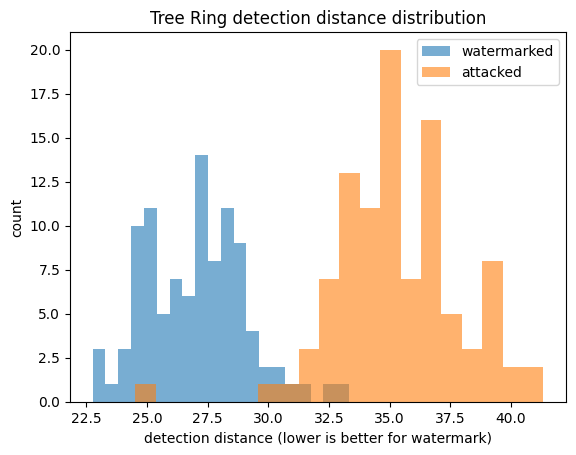

In [ ]:
plt.figure()
plt.hist(wm_vals, bins=20, alpha=0.6, label="watermarked")
plt.hist(atk_vals, bins=20, alpha=0.6, label="attacked")
plt.xlabel("detection distance (lower is better for watermark)")
plt.ylabel("count")
plt.legend()
plt.title("Tree Ring detection distance distribution")
plt.show()


In [ ]:
neg_dir = "/content/drive/MyDrive/Treering_pipeline/outputs/colab_100/no_wm"


In [ ]:
# neg_dir = None  # change this to your non watermarked folder path when you have it

if neg_dir is not None:
    neg_scores = evaluate_dir(
        neg_dir,
        pipe,
        inv_scheduler,
        watermarker,
        w_channel=3,
        num_inference_steps=num_inference_steps,
        max_images=max_eval_images,
    )

    neg_vals = summarize_scores("No watermark", neg_scores)

    # Scores for ROC: we want a higher score for "more watermarked"
    # Our distance is smaller for positives, so score = -distance
    y_true = np.array([1] * len(wm_vals) + [0] * len(neg_vals))
    y_score = np.concatenate([-wm_vals, -neg_vals])

    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)

    print(f"AUC (watermarked vs no watermark): {roc_auc:.4f}")

    # TPR at 1 percent FPR
    target_fpr = 0.01
    idx = np.argmin(np.abs(fpr - target_fpr))
    print(f"TPR at FPR≈{fpr[idx]:.4f}: {tpr[idx]:.4f}")

    plt.figure()
    plt.plot(fpr, tpr)
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.title("ROC curve for Tree Ring detection")
    plt.grid(True)
    plt.show()
else:
    print("No directory of non watermarked images set. Skipping ROC computation.")


Evaluating 0 images from /content/drive/MyDrive/Treering_pipeline/outputs/colab_100/no_watermark


no_watermark: 0it [00:00, ?it/s]

/tmp/ipython-input-3627355181.py:5: RuntimeWarning: Mean of empty slice.
  print(f"{name}  count={len(vals)}  mean={vals.mean():.4f}  std={vals.std():.4f}  "
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:218: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:175: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:210: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


ValueError: zero-size array to reduction operation minimum which has no identity